<font size="6"><span style="font-weight: 500;">RFM-анализ продаж британского магазина</span></font>

<font size="4" ><span style="font-weight: 500;">Цель иследования</span></font>

<font size="2" >Изучить и проанализировать клиентскую базу магазина через историю покупок и провести сегментацию покупателей, определить самых ценных для бизнеса.</font>


<font size="4" ><span style="font-weight: 500;">Обзор данных их датасета</span></font>

In [ ]:
!pip install pandas numpy matplotlib seaborn scipy squarify

In [2]:
import pandas as pd
import squarify
import datetime as dt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
from scipy import stats

In [3]:
df = pd.read_csv('data/online_retail.csv', encoding='latin1')

print("Размер датасета", df.shape)

Размер датасета (541910, 8)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  str    
 1   StockCode    541910 non-null  str    
 2   Description  540456 non-null  str    
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  str    
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


Датасет Online Retail II содержит информацию о продажах интернет-магазина, и состоит из следующих 8 основных колонок.

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


1. Invoice - номер транзакции
2. StockCode - Код продаваемого товара
3. Description - Описание продаваемого товара
4. Quantity - Количество проданного товара в рамках одной транзакции
5. InvoiceDate - Дата и время проведения транзакции
6. Price - Цена за одну единиицу товара
7. Customer ID - ID клиента
8. Country - наименование страны, в которой проживает покупатель

<font size="4" ><span style="font-weight: 500;">Предобработка данных</span></font>

Приведем дату к типу *datetime*. Далее очистим данные, а именно: удалим строки без Customer ID, строки где цена или количетсво отрицательные значения.
Также в условиях указано, что если значение атрибута "Invoice" начинается c "С", значит операция отменена - такие записи мы также удаляем. 

In [6]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')
df = df.dropna(subset=['Customer ID'])
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

Проверим, есть ли строки с пропущенными значениями.

In [7]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

Посмотрим есть ли в выборке дубликаты.

In [8]:
print(df.duplicated().sum())

5192


В нешей выборке нашлись дубликаты - удалим их.

In [9]:
df = df.drop_duplicates()

Вывидим сводную статистику и посмотрим на аномальные значения в нашем измененном датасэте

In [10]:
stats = df[['Quantity', 'Price', 'Customer ID']].describe().T

stats

,count,mean,std,min,25%,50%,75%,max
Quantity,392693.0,13.119671,180.492603,1.000,2.00,6.00,12.00,80995.00
Price,392693.0,3.125952,22.241820,0.001,1.25,1.95,3.75,8142.75
Customer ID,392693.0,15287.837224,1713.542421,12346.000,13955.00,15150.00,16791.00,18287.00


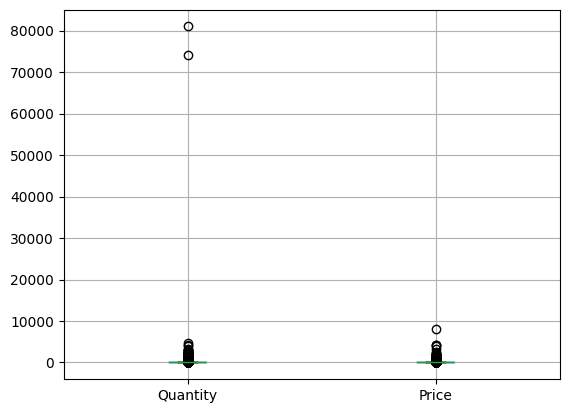

In [11]:
df[["Quantity","Price"]].boxplot()
plt.show()

Исходя из сводной статистики в выборке присутствуют выбросы. Взглянем на них.

In [12]:
df[df['Quantity'] > 70000]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom


In [13]:
df[df['Price'] > 5000]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom


Данные записи являются скорее всего особо крупными оптовыми продажами чем аномалиями. 
Было принято решение оставить их в выборке.

<font size="4" ><span style="font-weight: 500;">RFM анализ</span></font>

<font size="2" >Recency</font>

Определим временной промежуток продаж

In [14]:
print("Min Date:", df["InvoiceDate"].min(),"  Max Date:", df["InvoiceDate"].max())

Min Date: 2010-12-01 08:26:00   Max Date: 2011-12-09 12:50:00


Вычисляем *recency* - производим группировку по ID покупателя, далее для каждой группы находим макисмальное значение в столбце InvoiceDate и вычитаем его из нашего общего максимума - получаем давность последней покупки для каждого клиента. В новой таблице с *recency* переименуем столбец для удобства.

In [15]:
recency = (dt.datetime(2011, 12, 9) - df.groupby("Customer ID").agg({"InvoiceDate":"max"})).rename(columns = {"InvoiceDate":"Recency"})

recency

,Recency
Customer ID,
12346.0,324 days 13:59:00
12347.0,1 days 08:08:00
12348.0,74 days 10:47:00
12349.0,17 days 14:09:00
12350.0,309 days 07:59:00
...,...
18280.0,276 days 14:08:00
18281.0,179 days 13:07:00
18282.0,6 days 12:17:00


<font size="2" >Frequency</font>

Далее высчитываем частоту покупок для каждого покупателя. Для этого группируем исходные данные по ID покупателя, далее для каждого покупателя собираем список угикальных покупок и считаем их количество. Переименовываем заголовок столбца на *Frequency*.

In [16]:
freq = df.groupby("Customer ID").agg({"Invoice":"nunique"}).rename(columns={"Invoice": "Frequency"})
freq

,Frequency
Customer ID,
12346.0,1
12347.0,7
12348.0,4
12349.0,1
12350.0,1
...,...
18280.0,1
18281.0,1
18282.0,2


<font size="2" >Monetary</font>

Далее считаем метрику *monetary*, которая показывает сколько каждый покупатель суммарно всего потратил за все время в нашем магазине. 
Для этого сначала нужно высчитать дополнительно для каждой записи итоговую сумму.

In [17]:
df["TotalPrice"] = df["Quantity"] * df["Price"]

Далее высчитываем *monetary* - просто группируем строки по ID покупателя, для каждого покупателя считаем сумму "TotalPrice".  

In [18]:
monetary = df.groupby("Customer ID").agg({"TotalPrice":"sum"}).rename(columns={"TotalPrice":"Monetary"})
monetary

,Monetary
Customer ID,
12346.0,77183.60
12347.0,4310.00
12348.0,1797.24
12349.0,1757.55
12350.0,334.40
...,...
18280.0,180.60
18281.0,80.82
18282.0,178.05


Далее объеденяем наши данные в одну таблицу, что бы на основе ее провести сегментацию.

In [19]:
rfm = pd.concat([recency, freq, monetary],  axis=1)
rfm

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,324 days 13:59:00,1,77183.60
12347.0,1 days 08:08:00,7,4310.00
12348.0,74 days 10:47:00,4,1797.24
12349.0,17 days 14:09:00,1,1757.55
12350.0,309 days 07:59:00,1,334.40
...,...,...,...
18280.0,276 days 14:08:00,1,180.60
18281.0,179 days 13:07:00,1,80.82
18282.0,6 days 12:17:00,2,178.05


<font size="4" ><span style="font-weight: 500;">Проводим RFM оценку</span></font>

Высчитываем RFM оценку. 
Для этого нужно вычислить оценку для каждой метрики
Для *FrequencyScore* проводим ранжирование (по порядку появления) так как Frequency имеет много одинаковых значений, а функция pd.qcut работает только с уникиальными значениями. 

In [20]:
rfm["RecencyScore"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1])
rfm["FrequencyScore"]= pd.qcut(rfm["Frequency"].rank(method="first"),5, labels=[1,2,3,4,5])
rfm["MonetaryScore"] = pd.qcut(rfm['Monetary'], 5, labels = [1, 2, 3, 4, 5])
rfm.head()

,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore
Customer ID,,,,,,
12346.0,324 days 13:59:00,1,77183.60,1,1,5
12347.0,1 days 08:08:00,7,4310.00,5,5,5
12348.0,74 days 10:47:00,4,1797.24,2,4,4
12349.0,17 days 14:09:00,1,1757.55,4,1,4
12350.0,309 days 07:59:00,1,334.40,1,1,2


Полученные значения собираем в FRM оценку.

In [21]:
rfm["RFM-score"] = (rfm['RecencyScore'].astype(str) + 
                     rfm['FrequencyScore'].astype(str) + 
                     rfm['MonetaryScore'].astype(str))
rfm.head()

,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM-score
Customer ID,,,,,,,
12346.0,324 days 13:59:00,1,77183.60,1,1,5,115
12347.0,1 days 08:08:00,7,4310.00,5,5,5,555
12348.0,74 days 10:47:00,4,1797.24,2,4,4,244
12349.0,17 days 14:09:00,1,1757.55,4,1,4,414
12350.0,309 days 07:59:00,1,334.40,1,1,2,112


Создаем словарь для сегментации наших клиентов.

In [22]:
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Loose',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

rfm['Segment'] = (rfm['RecencyScore'].astype(str) + rfm['FrequencyScore'].astype(str)).replace(seg_map, regex=True)
rfm.head()

,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM-score,Segment
Customer ID,,,,,,,,
12346.0,324 days 13:59:00,1,77183.60,1,1,5,115,Hibernating
12347.0,1 days 08:08:00,7,4310.00,5,5,5,555,Champions
12348.0,74 days 10:47:00,4,1797.24,2,4,4,244,At Risk
12349.0,17 days 14:09:00,1,1757.55,4,1,4,414,Promising
12350.0,309 days 07:59:00,1,334.40,1,1,2,112,Hibernating


Каждому покупателю было присвоино наименование сегмента, к которому он относится.

In [23]:
rfmstats = rfm[["Segment","Recency","Frequency", "Monetary"]].groupby("Segment").agg(["mean","median","count", "std"])
rfmstats.columns = rfmstats.columns.map('_'.join).str.strip('|')
rfmstats

,Recency_mean,Recency_median,Recency_count,Recency_std,Frequency_mean,Frequency_median,Frequency_count,Frequency_std,Monetary_mean,Monetary_median,Monetary_count,Monetary_std
Segment,,,,,,,,,,,,
About to Sleep,51 days 10:29:47.627118,51 days 11:35:30,354,11 days 00:39:04.291772,1.161017,1.0,354,0.368067,467.692006,326.075,354,532.070308
At Risk,151 days 16:32:18.291457,135 days 13:40:00,597,68 days 17:03:01.186243,2.876047,3.0,597,0.949061,1080.225831,675.600,597,2553.041325
Can't Loose,129 days 12:58:06.461538,104 days 11:24:00,65,65 days 01:50:57.837731,8.353846,7.0,65,4.225779,2778.464923,2203.670,65,2072.771010
Champions,4 days 19:38:47.014218,3 days 13:22:00,633,3 days 16:24:54.303937,12.413902,8.0,633,16.451672,6843.188957,2599.030,633,20332.592752
Hibernating,215 days 18:59:02.068965,217 days 14:16:00,1073,92 days 03:32:10.553169,1.101584,1.0,1073,0.302242,488.095948,292.470,1073,2417.478356
Loyal Customers,31 days 22:06:07.941176,28 days 05:07:30,816,15 days 10:17:07.349610,6.481618,5.0,816,4.552047,2858.177281,1727.740,816,6013.431868
Need Attention,50 days 06:15:03.850267,50 days 09:20:00,187,11 days 12:53:43.207464,2.315508,2.0,187,0.465965,892.843583,637.500,187,1102.247575
New Customers,5 days 21:07:08.571428,6 days 10:36:30,42,3 days 21:51:13.427510,1.000000,1.0,42,0.000000,385.022381,274.505,42,570.957168
Potential Loyalists,15 days 15:45:15.188284,16 days 10:42:00,478,9 days 05:30:02.451957,2.016736,2.0,478,0.650538,1041.612657,516.225,478,7704.051063


In [24]:
monetary_per = rfm.groupby("Segment")["Monetary"].sum()/rfm["Monetary"].sum()*100
customer_per = rfm.groupby("Segment").size() / len(rfm) * 100
summary = pd.DataFrame({
    "Monetary_%": monetary_per.round(2),
    "Customers_%": customer_per.round(2)
})
summary.sort_values("Monetary_%", ascending=False)

,Monetary_%,Customers_%
Segment,,
Champions,48.74,14.59
Loyal Customers,26.24,18.81
At Risk,7.26,13.76
Hibernating,5.89,24.73
Potential Loyalists,5.60,11.02
Can't Loose,2.03,1.50
Need Attention,1.88,4.31
About to Sleep,1.86,8.16
Promising,0.31,2.14


<font size="4" ><span style="font-weight: 500;">Визуализация данных</span></font>

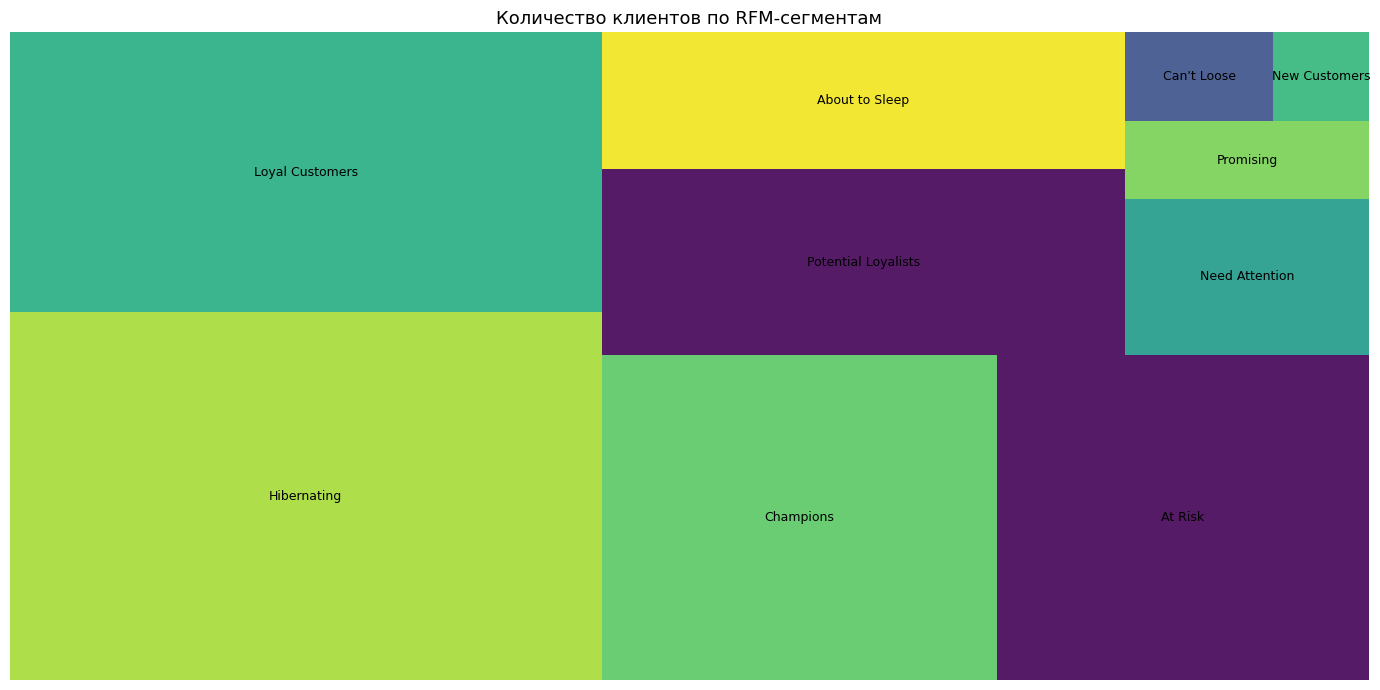

In [25]:
segment_counts = rfm['Segment'].value_counts()
labels = segment_counts.index.tolist()
plt.figure(figsize=(14, 7))
squarify.plot(
    sizes=segment_counts.values,
    label=labels,
    alpha=0.9,
    pad=False,            
    text_kwargs={'fontsize': 9}
)
plt.title('Количество клиентов по RFM-сегментам', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()


<font size="4" ><span style="font-weight: 500;">Выводы </span></font>

Исходя из данных по сводным таблицам можно отметить, что на "Champions" приходится 48% выручки, хотя они составляют 14,5% от общего числа покупателей.

Аналогичная ситуация стоит и с "Loyal Customers" - 26% выручки на почти 19% от общего числа покупателей. Таким образом два этих основных сегмента, котоыре составляют треть всех покупатеоей, приносят почти 75% выручки всего магазина. 

По итогу получается, что выручка магазина находится в зависимости от данного круга клиентов, следоавтельно их удержание должно быть приоритетной задачей.

Противоположная ситуация стоит с самым большим сегментом - "Hibernating" - он занимает почти четверть ~ 25% от общего числа покупателей, но приносит всего 5,8% прибыли, а исходя то что в среднем они покупали последний раз 215 дней назад этот сегмент не стоит внимания и является наименее ценным для бизнеса.

На кого стоит обратить внимание так это сегмент "Can't Loose" - у них довольная хорошая частота покупок несмотря на немногочисленность - всего 65 человек. Из проблем - их Recency 129 дней поэтому таких клиентов надо реактивировать и стараться удержать, так как зачастую возвращение таких клиентов гораздо дороже чем их удержание.

Сегмент «At Risk» — требует внимание так как там неплохой процент клиентов. Сейчас это 597 человека ~ 14%. Но из проблем они не покупали уже 5 месяцев, при этом каждый приносит в среднем Monetary большее 1000 . Это огромный пласт клиентов, которых надо возвращать.
В онлайн магазине достаточно провести рассылку или дать скидку - это может помочь вернуть их и принести серьёзную выручку. Если ничего не делать, то люди из этого сегмента перейдут в сегмент «Hibernating», и тогда вернуть их будет в разы сложнее и дороже.

"New Customers" и "Promising" - этот сегменты отвечают за новых покупателей. Всего 42 и 93 клиента соответственно, с частотой покупок 1 — это ожидаемо для новых клиентов. Их совокупный вклад в выручку минимален - меньше одного процента, но такие люди могут в будущем попасть в сегмент "Loyal Customers" и "Champions" - важно выстроить правильное взаимодействие с покупателем - реклама, онбординг, напрмиер: предлагать произвести вторую покупку.

Если подводить общий итог то можно выявить следующие факты:
1. Бизнес держится на относительно небольшом ядре лояльных клиентов.
2. Почти четверть базы - сегмент "Hibernating" - это спящие/ушедшие клиенты с минимальным вкладом в выручку - тратить деньги на их возвращение невыгодно.
3. Наибольший ROI от маркетинговых усилий стоит ожидать от удержания сегментов "Champions" и "Loyal Customers", и точечной реактивации для "Can't Loose", а также масштабной, но недорогой реактивации "At Risk".